In [1]:
# ============================================================
# Battery Dispatch Germany — DA Analysis
# ============================================================
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Load ────────────────────────────────────────────────────
daily  = pd.read_csv('../outputs/daily_revenue_20260613_2004.csv')
hourly = pd.read_csv('../outputs/hourly_detialed_data20260613_2004.csv')

daily['date']  = pd.to_datetime(daily['date'])
hourly['date'] = pd.to_datetime(hourly['date'])

# Fix -0.0 floating point noise from solver
hourly['charge']    = hourly['charge'].clip(lower=0)
hourly['discharge'] = hourly['discharge'].clip(lower=0)
hourly['pnl']       = (hourly['discharge'] - hourly['charge']) * hourly['price']

# ── Enrich daily ────────────────────────────────────────────
day_agg = hourly.groupby('date').agg(
    price_spread  = ('price', lambda x: x.max() - x.min()),
    min_price     = ('price', 'min'),
    max_price     = ('price', 'max'),
    neg_hours     = ('price', lambda x: (x < 0).sum()),
    total_charge  = ('charge', 'sum'),
    total_discharge = ('discharge', 'sum'),
).reset_index()

daily = daily.merge(day_agg, on='date')
daily['month']     = daily['date'].dt.to_period('M').astype(str)
daily['dow']       = daily['date'].dt.day_name()

# ── Monthly table ───────────────────────────────────────────
monthly = daily.groupby('month').agg(
    total_revenue = ('revenue', 'sum'),
    days          = ('revenue', 'count'),
    avg_daily     = ('revenue', 'mean'),
    best_day      = ('revenue', 'max'),
    avg_spread    = ('price_spread', 'mean'),
    avg_neg_hours = ('neg_hours', 'mean'),
).round(1)

print("=" * 65)
print("MONTHLY SUMMARY — Germany DA Battery Dispatch 1MW/2MWh")
print("=" * 65)
print(monthly.to_string())
print(f"\nTotal Revenue (Jan–May 2026): €{daily['revenue'].sum():,.0f}")
print(f"Days optimised: {len(daily)} | Infeasible: 0")
print(f"Avg daily revenue: €{daily['revenue'].mean():.0f}")
print(f"Best day: {daily.loc[daily['revenue'].idxmax(), 'date'].date()} "
      f"→ €{daily['revenue'].max():,.0f}")

MONTHLY SUMMARY — Germany DA Battery Dispatch 1MW/2MWh
         total_revenue  days  avg_daily  best_day  avg_spread  avg_neg_hours
month                                                                       
2026-01         2441.8    31       78.8     289.3        72.8            0.1
2026-02         1855.1    28       66.3     201.6        63.8            0.2
2026-03         7373.4    30      245.8     425.6       157.5            1.0
2026-04         8739.1    30      291.3    1144.9       176.9            4.1
2026-05         8942.8    31      288.5    1323.7       181.1            2.5

Total Revenue (Jan–May 2026): €29,352
Days optimised: 150 | Infeasible: 0
Avg daily revenue: €196
Best day: 2026-05-01 → €1,324


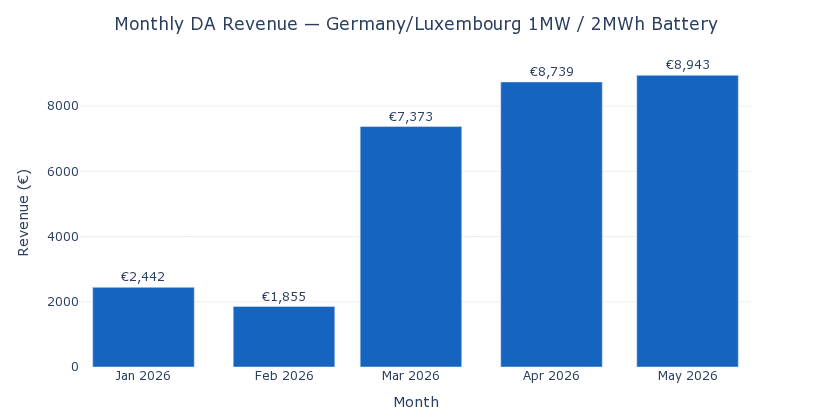

In [2]:
# Monthly Revenue Bar Chart
fig1 = go.Figure()

fig1.add_trace(go.Bar(
    x=monthly.index,
    y=monthly['total_revenue'],
    marker_color='#1565C0',
    text=[f'€{v:,.0f}' for v in monthly['total_revenue']],
    textposition='outside',
    name='DA Revenue',
))

fig1.update_layout(
    title=dict(text='Monthly DA Revenue — Germany/Luxembourg 1MW / 2MWh Battery', x=0.5),
    xaxis_title='Month',
    yaxis_title='Revenue (€)',
    plot_bgcolor='white',
    yaxis=dict(gridcolor='#eeeeee', zeroline=False),
    height=420,
    margin=dict(t=60, b=50),
)
fig1.show()

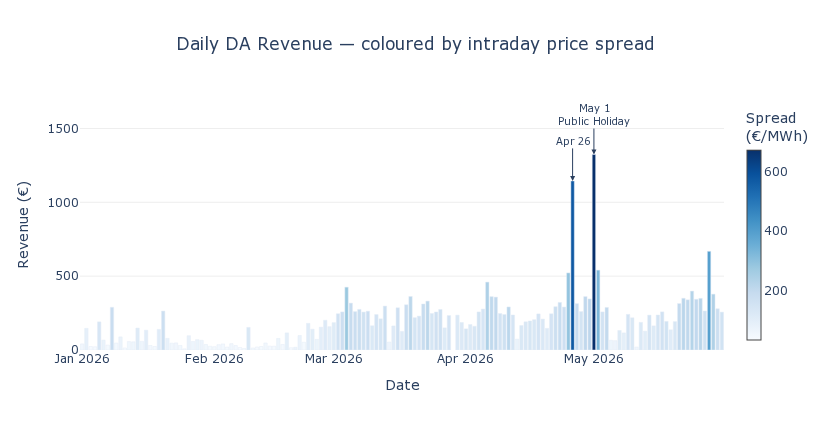

In [3]:
# Daily Revenue Timeline coloured by price spread
fig2 = go.Figure()

fig2.add_trace(go.Bar(
    x=daily['date'],
    y=daily['revenue'],
    marker=dict(
        color=daily['price_spread'],
        colorscale='Blues',
        colorbar=dict(title='Spread<br>(€/MWh)', thickness=14),
        showscale=True,
    ),
    hovertemplate=(
        '<b>%{x|%b %d}</b><br>'
        'Revenue: €%{y:.0f}<br>'
        'Spread: €%{marker.color:.0f}<extra></extra>'
    ),
))

# Annotate the two extreme outliers
for date, label in [('2026-05-01', 'May 1<br>Public Holiday'),
                     ('2026-04-26', 'Apr 26')]:
    row = daily[daily['date'] == date].iloc[0]
    fig2.add_annotation(
        x=row['date'], y=row['revenue'],
        text=label, showarrow=True,
        arrowhead=2, ax=0, ay=-40,
        font=dict(size=10),
    )

fig2.update_layout(
    title=dict(text='Daily DA Revenue — coloured by intraday price spread', x=0.5),
    xaxis_title='Date',
    yaxis_title='Revenue (€)',
    plot_bgcolor='white',
    yaxis=dict(gridcolor='#eeeeee'),
    height=430,
)
fig2.show()

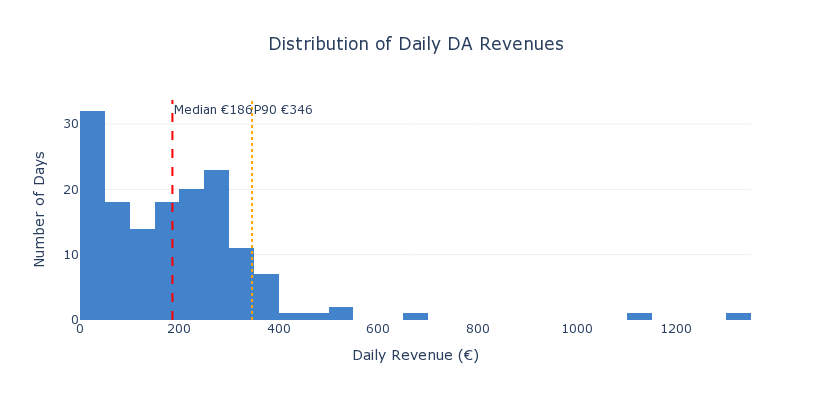

Top 10% of days (15 days) → 27% of total revenue
Revenue is highly concentrated — classic in energy arbitrage


In [4]:
# Distribution of Daily Revenues
p50  = daily['revenue'].median()
p90  = daily['revenue'].quantile(0.9)
top15 = daily.nlargest(15, 'revenue')['revenue'].sum()
top15_pct = top15 / daily['revenue'].sum()

fig3 = go.Figure()
fig3.add_trace(go.Histogram(
    x=daily['revenue'],
    nbinsx=35,
    marker_color='#1565C0',
    opacity=0.8,
    name='Days',
))
fig3.add_vline(x=p50, line_dash='dash', line_color='red',
               annotation_text=f'Median €{p50:.0f}',
               annotation_position='top right')
fig3.add_vline(x=p90, line_dash='dot', line_color='orange',
               annotation_text=f'P90 €{p90:.0f}',
               annotation_position='top right')

fig3.update_layout(
    title=dict(text='Distribution of Daily DA Revenues', x=0.5),
    xaxis_title='Daily Revenue (€)',
    yaxis_title='Number of Days',
    plot_bgcolor='white',
    yaxis=dict(gridcolor='#eeeeee'),
    height=400,
)
fig3.show()

print(f"Top 10% of days (15 days) → {top15_pct:.0%} of total revenue")
print(f"Revenue is highly concentrated — classic in energy arbitrage")

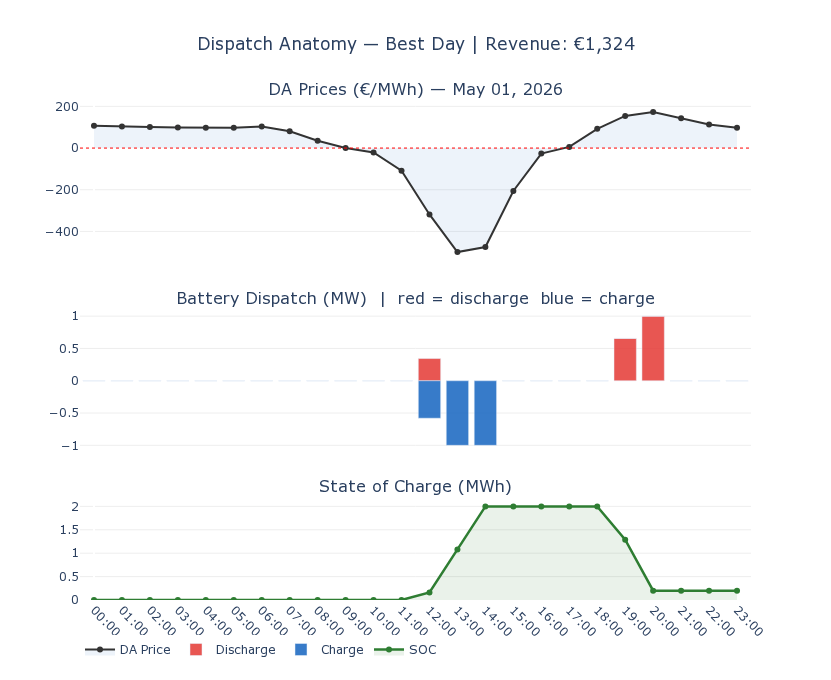

In [6]:
# Best Day Dispatch Anatomy
best_date = daily.loc[daily['revenue'].idxmax(), 'date']
best_rev  = daily['revenue'].max()
day_h     = hourly[hourly['date'] == best_date].sort_values('hour')

fig4 = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,
    subplot_titles=[
        f'DA Prices (€/MWh) — {best_date.strftime("%B %d, %Y")}',
        'Battery Dispatch (MW)  |  red = discharge  blue = charge',
        'State of Charge (MWh)',
    ],
    vertical_spacing=0.09,
    row_heights=[0.4, 0.35, 0.25],
)

hours = list(range(24))

# Panel 1 — prices
fig4.add_trace(go.Scatter(
    x=hours, y=day_h['price'],
    mode='lines+markers',
    line=dict(color='#333', width=2),
    fill='tozeroy',
    fillcolor='rgba(21,101,192,0.08)',
    name='DA Price',
), row=1, col=1)
fig4.add_hline(y=0, line_dash='dot', line_color='red',
               line_width=1, row=1, col=1)

# Panel 2 — charge / discharge (mirrored bar)
fig4.add_trace(go.Bar(
    x=hours, y=day_h['discharge'],
    name='Discharge', marker_color='#E53935', opacity=0.85,
), row=2, col=1)
fig4.add_trace(go.Bar(
    x=hours, y=-day_h['charge'],
    name='Charge', marker_color='#1565C0', opacity=0.85,
), row=2, col=1)

# Panel 3 — SOC
fig4.add_trace(go.Scatter(
    x=hours, y=day_h['soc'],
    mode='lines+markers',
    line=dict(color='#2E7D32', width=2.5),
    fill='tozeroy',
    fillcolor='rgba(46,125,50,0.10)',
    name='SOC',
), row=3, col=1)

fig4.update_xaxes(tickvals=hours, ticktext=[f'{h:02d}:00' for h in hours],
                  tickangle=45, row=3, col=1)
fig4.update_layout(
    title=dict(
        text=f'Dispatch Anatomy — Best Day | Revenue: €{best_rev:,.0f}',
        x=0.5),
    plot_bgcolor='white',
    barmode='relative',
    height=680,
    legend=dict(orientation='h', y=-0.07),
    showlegend=True,
)
fig4.update_yaxes(gridcolor='#eeeeee')
fig4.show()

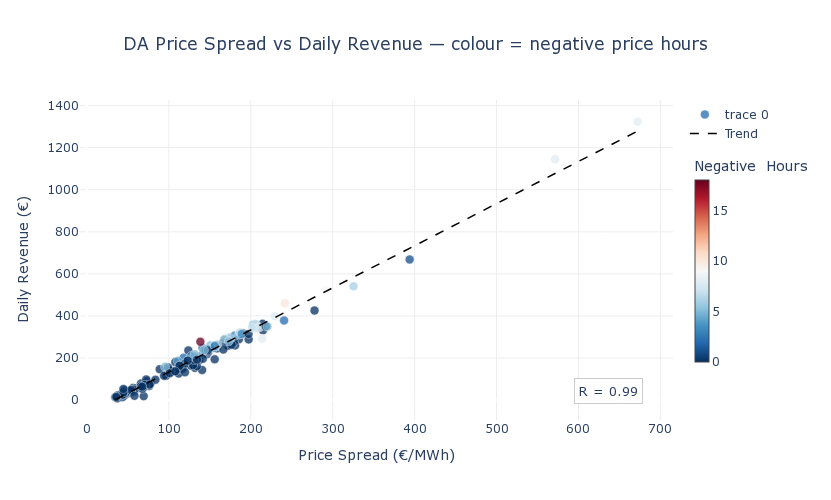

In [20]:
# Price Spread vs Revenue Scatter
fig5 = go.Figure()

fig5.add_trace(go.Scatter(
    x=daily['price_spread'],
    y=daily['revenue'],
    mode='markers',
    marker=dict(
        color=daily['neg_hours'],
        colorscale='RdBu',
        reversescale=True,
        colorbar=dict(title='Negative  Hours', thickness=14, len=0.7,),
        size=9,
        opacity=0.75,
        showscale=True,
        line=dict(width=0.5, color='white'),
    ),
    text=daily['date'].dt.strftime('%b %d'),
    hovertemplate=(
        '<b>%{text}</b><br>'
        'Spread: €%{x:.0f}<br>'
        'Revenue: €%{y:.0f}<extra></extra>'
    ),
))

# Trendline
z = np.polyfit(daily['price_spread'], daily['revenue'], 1)
x_line = np.linspace(daily['price_spread'].min(), daily['price_spread'].max(), 200)
fig5.add_trace(go.Scatter(
    x=x_line, y=np.polyval(z, x_line),
    mode='lines', name='Trend',
    line=dict(color='black', dash='dash', width=1.5),
    showlegend=True,
))

# R² label
corr = daily[['price_spread','revenue']].corr().iloc[0,1]
fig5.add_annotation(
    x=0.95, y=0.05, xref='paper', yref='paper',  
    text=f'R = {corr:.2f}',
    showarrow=False,
    font=dict(size=13),
    bgcolor='white',
    bordercolor='#ccc',
    borderwidth=1,
    borderpad=4,
)

fig5.update_layout(
    title=dict(text='DA Price Spread vs Daily Revenue — colour = negative price hours', x=0.5),
    xaxis_title='Price Spread (€/MWh)',  # Fixed typo: was "Intraday" but this is DA
    yaxis_title='Daily Revenue (€)',
    plot_bgcolor='white',
    yaxis=dict(gridcolor='#eeeeee'),
    xaxis=dict(gridcolor='#eeeeee'),
    margin=dict(r=100),  # Add right margin for colorbar
    height=500,
)
fig5.show()

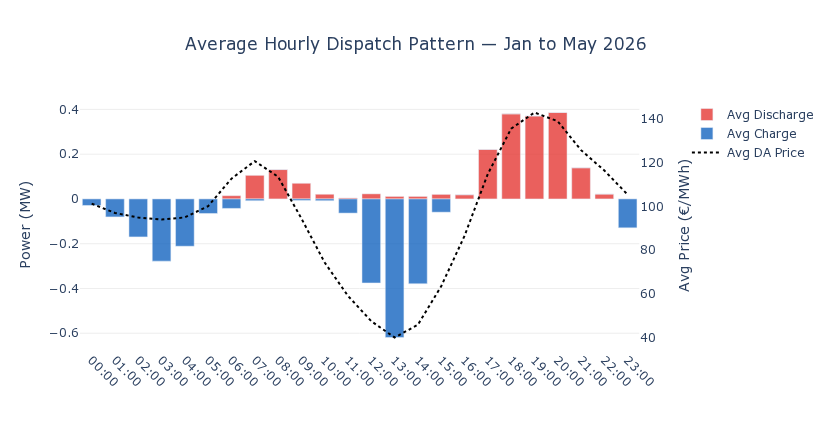

In [8]:
avg_hourly = hourly.groupby('hour')[['charge','discharge','price']].mean()

fig6 = make_subplots(specs=[[{"secondary_y": True}]])

fig6.add_trace(go.Bar(
    x=avg_hourly.index,
    y=avg_hourly['discharge'],
    name='Avg Discharge', marker_color='#E53935', opacity=0.8,
), secondary_y=False)

fig6.add_trace(go.Bar(
    x=avg_hourly.index,
    y=-avg_hourly['charge'],
    name='Avg Charge', marker_color='#1565C0', opacity=0.8,
), secondary_y=False)

fig6.add_trace(go.Scatter(
    x=avg_hourly.index,
    y=avg_hourly['price'],
    name='Avg DA Price',
    line=dict(color='black', width=2, dash='dot'),
), secondary_y=True)

fig6.update_layout(
    title=dict(text='Average Hourly Dispatch Pattern — Jan to May 2026', x=0.5),
    xaxis=dict(tickvals=list(range(24)),
               ticktext=[f'{h:02d}:00' for h in range(24)], tickangle=45),
    barmode='relative',
    plot_bgcolor='white',
    yaxis=dict(title='Power (MW)', gridcolor='#eee'),
    yaxis2=dict(title='Avg Price (€/MWh)'),
    height=430,
)
fig6.show()

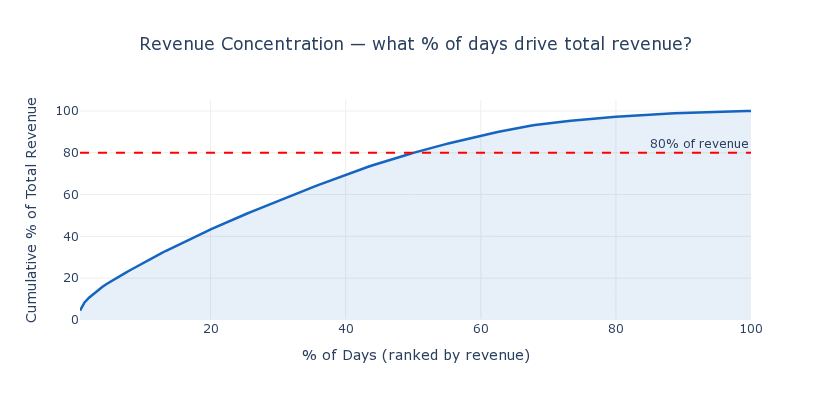

80% of revenue comes from the top 51% of days


In [9]:
daily_sorted = daily.sort_values('revenue', ascending=False).reset_index(drop=True)
daily_sorted['cumulative_pct'] = daily_sorted['revenue'].cumsum() / daily_sorted['revenue'].sum() * 100
daily_sorted['day_pct'] = (daily_sorted.index + 1) / len(daily_sorted) * 100

fig7 = go.Figure()
fig7.add_trace(go.Scatter(
    x=daily_sorted['day_pct'],
    y=daily_sorted['cumulative_pct'],
    mode='lines', fill='tozeroy',
    line=dict(color='#1565C0', width=2.5),
    fillcolor='rgba(21,101,192,0.1)',
))
fig7.add_hline(y=80, line_dash='dash', line_color='red',
               annotation_text='80% of revenue')
fig7.update_layout(
    title=dict(text='Revenue Concentration — what % of days drive total revenue?', x=0.5),
    xaxis_title='% of Days (ranked by revenue)',
    yaxis_title='Cumulative % of Total Revenue',
    plot_bgcolor='white',
    yaxis=dict(gridcolor='#eee'),
    xaxis=dict(gridcolor='#eee'),
    height=400,
)
fig7.show()

# Find the 80/20 point
p80 = daily_sorted[daily_sorted['cumulative_pct'] >= 80].iloc[0]
print(f"80% of revenue comes from the top {p80['day_pct']:.0f}% of days")